In [3]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

path = "3750_0.h5"

with h5py.File(path, "r") as f:
    for key in f.keys():
        obj = f[key]
        print(
            f"{key:10s}",
            "shape = ", obj.shape,
            "type = ", obj.dtype
        )

aoa        shape =  () type =  int32
re         shape =  () type =  int32
t          shape =  (868,) type =  float32
u          shape =  (868, 64, 128) type =  float64
v          shape =  (868, 64, 128) type =  float64
x          shape =  (64, 128) type =  float64
y          shape =  (64, 128) type =  float64


# At each (x, y) point 
We have corresponding u, v, t.
For instance, (x, y) = (20, 50) => at timestep (t) = 0, we have u[0, 20, 50] is an exact value.

u shape : (868, 64, 128)
v shape : (868, 64, 128)
x shape : (64, 128)
y shape : (64, 128)
t shape : (868,)
Re      : 3750
AoA     : 0


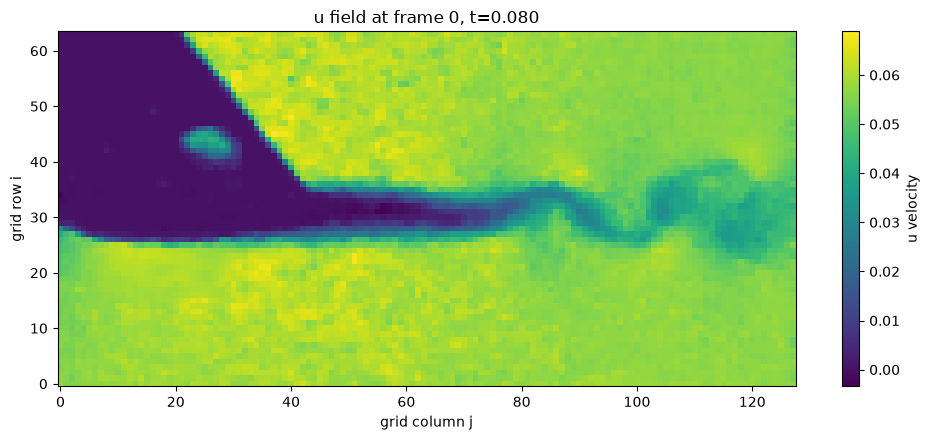

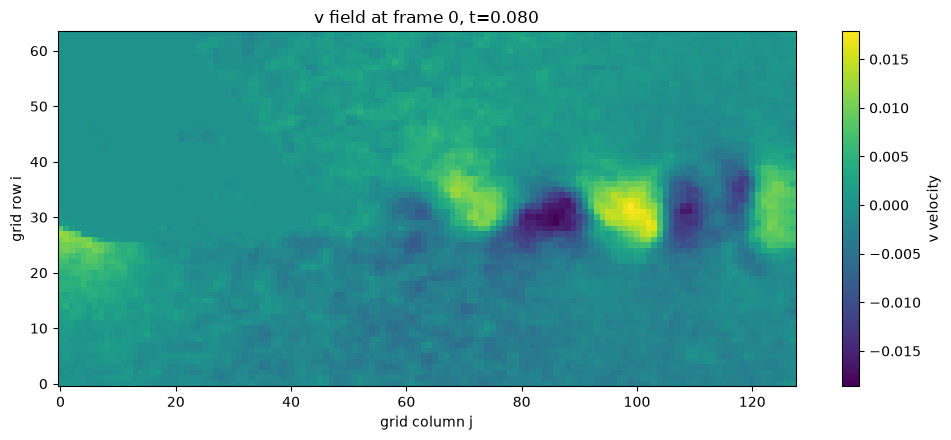

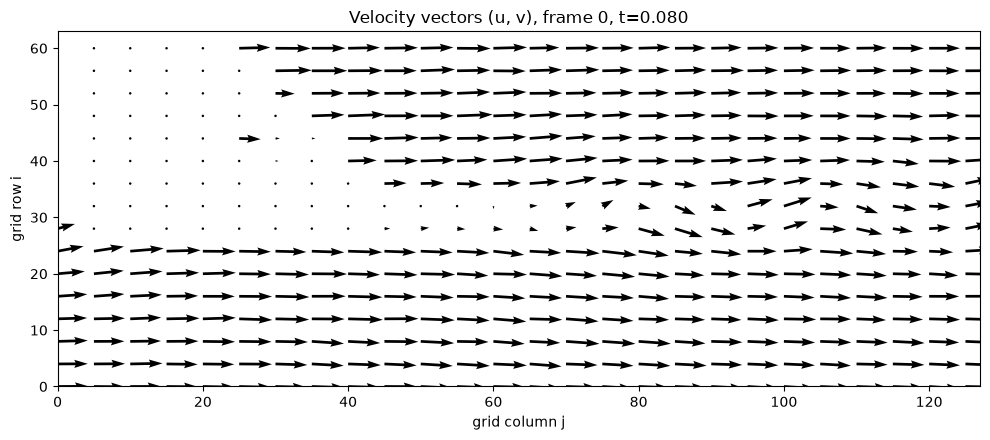

In [ ]:
import h5py
import numpy as np
import matplotlib.pyplot as plt


# =========================
# 1. Load data
# =========================

path = "3750_0.h5"

with h5py.File(path, "r") as f:
    u = f["u"][:]      # shape: (T, H, W)
    v = f["v"][:]      # shape: (T, H, W)
    x = f["x"][:]      # shape: (H, W)
    y = f["y"][:]      # shape: (H, W)
    t = f["t"][:]      # shape: (T,)

    re = np.array(f["re"]).item()
    aoa = np.array(f["aoa"]).item()


print("u shape :", u.shape)
print("v shape :", v.shape)
print("x shape :", x.shape)
print("y shape :", y.shape)
print("t shape :", t.shape)
print("Re      :", re)
print("AoA     :", aoa)

# =========================
# 5. Visualize velocity vectors
# =========================
#
# There are 64 x 128 = 8192 vectors.
# Plotting all of them is too dense,
# so we subsample the grid.
#

step_i = 4
step_j = 5

ii = np.arange(0, u0.shape[0], step_i)
jj = np.arange(0, u0.shape[1], step_j)

# grid coordinates for plotting
J, I = np.meshgrid(jj, ii)

# corresponding u, v values
U = u0[np.ix_(ii, jj)]
V = v0[np.ix_(ii, jj)]

plt.figure(figsize=(10, 4.5))

plt.quiver(
    J,
    I,
    U,
    V,
)

plt.title(
    f"Velocity vectors (u, v), "
    f"frame {frame_idx}, t={t[frame_idx]:.3f}"
)

plt.xlabel("grid column j")
plt.ylabel("grid row i")

plt.xlim(0, u0.shape[1] - 1)
plt.ylim(0, u0.shape[0] - 1)

plt.tight_layout()
plt.show()

In [6]:
# =========================
# 2. Choose one frame
# =========================

frame_idx = 0

u0 = u[frame_idx]
v0 = v[frame_idx]

print()
print("Selected frame:", frame_idx)
print("time:", t[frame_idx])
print("u0 shape:", u0.shape)
print("v0 shape:", v0.shape)



Selected frame: 0
time: 0.08
u0 shape: (64, 128)
v0 shape: (64, 128)


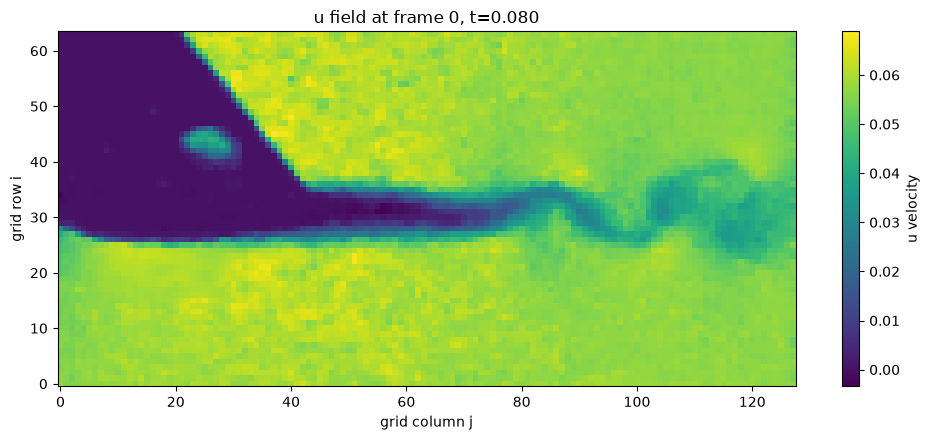

In [ ]:
# =========================
# 3. Visualize u
# =========================

plt.figure(figsize=(10, 4.5))

im = plt.imshow(
    u0,
    origin="lower",
    aspect="auto",
)

plt.colorbar(im, label="u velocity")
plt.title(f"u field at frame {frame_idx}, t={t[frame_idx]:.3f}")
plt.xlabel("grid column j")
plt.ylabel("grid row i")

plt.tight_layout()
plt.show()



# Visualize 1 file 3750_0.h5

In [8]:
import h5py
import numpy as np 
import matplotlib.pyplot as plt

### The file can be imagined as a folder with the following structure:
```
3750_0.h5
│
├── u
├── v
├── t
├── re
└── aoa
```

## The u, v, t file:
```
u
│
├── frame t=0  → 64 × 128
├── frame t=1  → 64 × 128
├── frame t=2  → 64 × 128
│
...
└── frame t=867 → 64 × 128
```

T = time dimensions  
H = grid points of 1 dimension  
W = grid points of the remaining dimension

For instance, u[0, 20, 50] là thành phần vận tốc u tại timestep = 0, row = 20, column = 50

In [9]:
path = "3750_0.h5"

with h5py.File(path, 'r') as f:
    u = f['u'][:] #[:] to get all the elements inside, read array, [()] read scalar
    v = f['v'][:]
    t = f['t'][:]
    re = np.asarray(f['re'][()].item() if 're' in f else None)
    aoa = np.asarray(f['aoa'][()].item() if 'aoa' in f else None)

print("u shape:", u.shape)
print("v shape:", v.shape)
print("t shape:", t.shape)
print("Re:", re)
print("AoA:", aoa)

print('u component: ', u[0, 20, 50])
print('v component: ', v[0, 20, 50])
print('t component: ', t[:5])

u shape: (868, 64, 128)
v shape: (868, 64, 128)
t shape: (868,)
Re: 3750
AoA: 0
u component:  0.06331814999999999
v component:  -0.0015991000000000002
t component:  [0.08 0.1  0.12 0.14 0.16]


In [10]:
# ============================================================
# 3. Compute speed magnitude
# ============================================================
#
# At each location:
#
# velocity vector = (u, v)
#
# speed = sqrt(u^2 + v^2)
#
# speed shape vẫn là:
# (T, H, W)
# ============================================================

speed = np.sqrt(u**2 + v**2)

print("speed shape:", speed.shape)
print('speed component - all spatial field at timestep 0:\n ', speed[0, 20, 50])
print("u:", u[0, 20, 50])
print("v:", v[0, 20, 50])
print("speed:", speed[0, 20, 50])
manual = np.sqrt(u[0, 20, 50]**2 + v[0, 20, 50]**2)
print(
    "manual:",
    manual
)

a = u[0, 20, 50]
b = speed[0, 20, 50]
print (b - manual)

print()

speed shape: (868, 64, 128)
speed component - all spatial field at timestep 0:
  0.06333833941802151
u: 0.06331814999999999
v: -0.0015991000000000002
speed: 0.06333833941802151
manual: 0.06333833941802151
0.0




Frames to visualize:
frame=   0, time=0.080
frame= 100, time=2.080
frame= 200, time=4.080
frame= 400, time=8.080
frame= 600, time=12.080
frame= 800, time=16.080

Global speed range:
min: 0.0
max: 0.07302511521834458


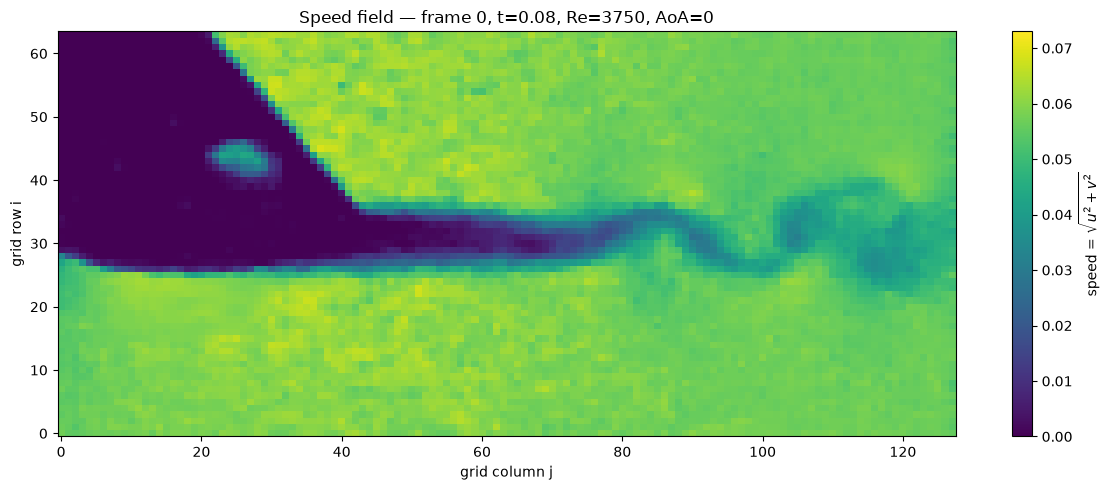

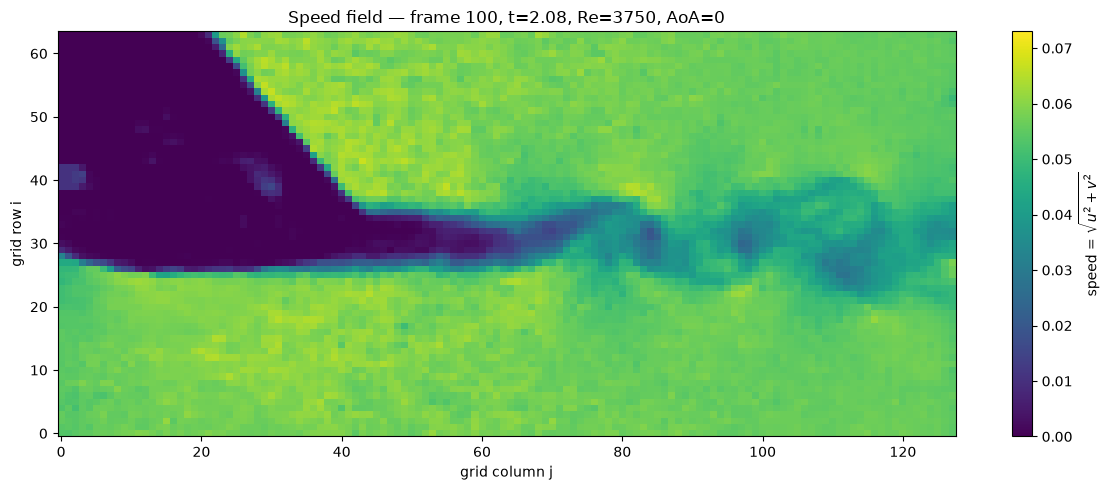

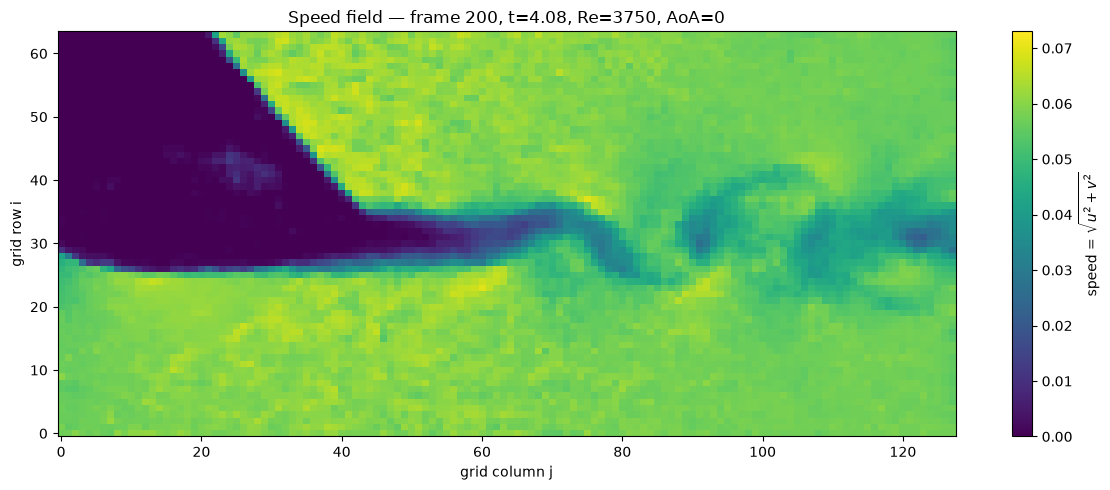

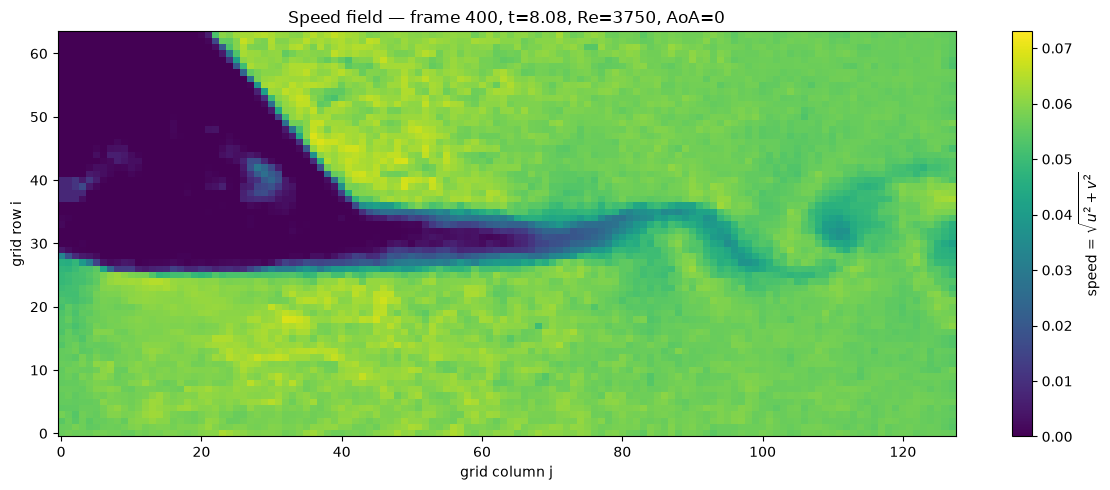

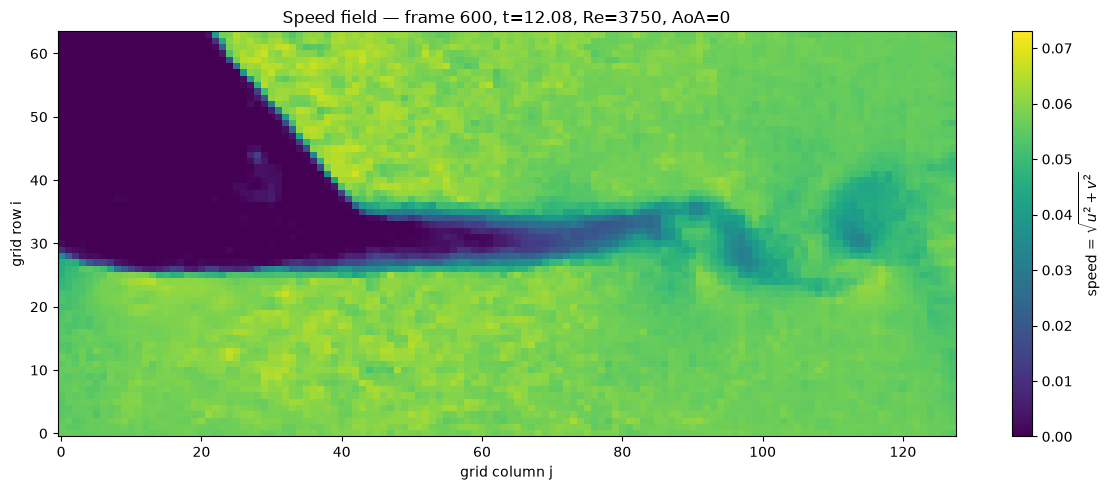

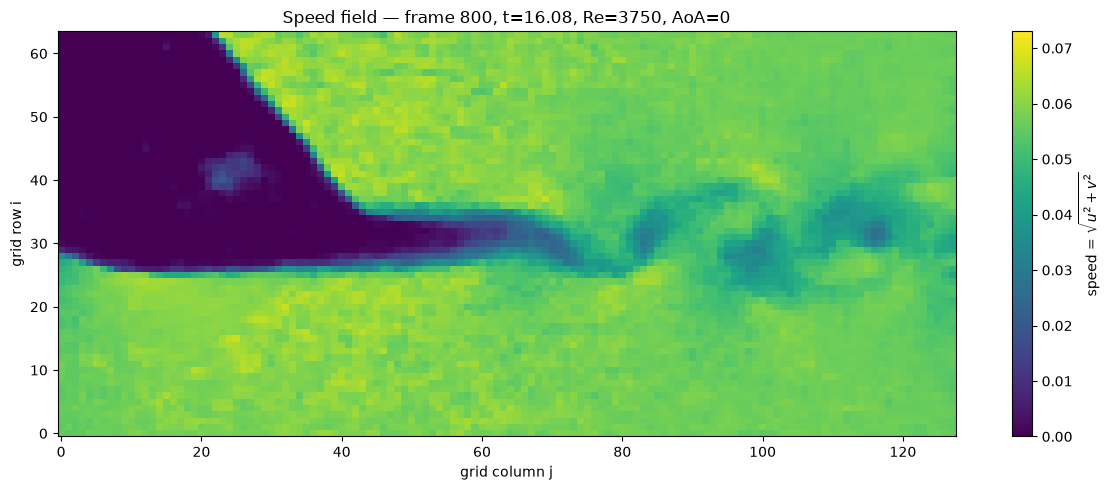

In [11]:


# ============================================================
# 4. Chọn các timestep muốn visualize
# ============================================================

frames = [0, 100, 200, 400, 600, 800]

# tránh lỗi nếu trajectory ngắn hơn
frames = [frame for frame in frames if frame < len(t)]

print("\nFrames to visualize:")
for frame in frames:
    print(
        f"frame={frame:4d}, "
        f"time={t[frame]:.3f}"
    )


# ============================================================
# 5. Giữ chung color scale cho tất cả hình
# ============================================================
#
# CỰC KỲ QUAN TRỌNG khi compare các frame.
#
# Nếu mỗi image tự chọn min/max riêng,
# cùng một màu có thể mang giá trị khác nhau giữa các frame.
# ============================================================

vmin = np.nanmin(speed)
vmax = np.nanmax(speed)

print("\nGlobal speed range:")
print("min:", vmin)
print("max:", vmax)


# ============================================================
# 6. Plot từng frame
# ============================================================

for frame in frames:

    plt.figure(figsize=(12, 5))

    im = plt.imshow(
        speed[frame],
        origin="lower",
        aspect="auto",
        vmin=vmin,
        vmax=vmax
    )

    plt.colorbar(
        im,
        label=r"speed = $\sqrt{u^2 + v^2}$"
    )

    plt.title(
        f"Speed field — frame {frame}, "
        f"t={t[frame]:.2f}, "
        f"Re={re}, AoA={aoa}"
    )

    plt.xlabel("grid column j")
    plt.ylabel("grid row i")

    plt.tight_layout()
    plt.show()